# Project Workflow

(1) Loaded the dataset – read the training images and labels. Dropping rows where label was not equal to 6 symbols due to excel formatting issues like 5.40E+12.

(2) Split the dataset – since we have no test labels, splitting the train dataset to 80/20 ratio to evaluate the model’s performance.

(3) Preprocessing images – applying CLAHE to all the images to help recover the blurred characters from the patches.

(4) Data augmentation – only to the training set adding some random transformations like blur, rotation, and black patches.

(5) Created the dictionary – went through the labels looking for unique characters and assigning index numbers to them. Index 0 will be reserved as CTC blank token.

(6) Defined the architecture – CNN network compressing image's height but keeping its width, BiLSTM reads the sequence both ways, FC output layer projecting to characters.

(7) Training – using CTC loss function to train the model without the knowledge about characters' positions across 50 timesteps.

(8) Validating – after each epoch calculating the Character Error Rate using the validation set and the greedy CTC approach saving the model when error decreased.

(9) Restoring best parameters – loading the best  saved weights and verify some predicted vs actual labels on validation set .

(10) Ran test inference — Passed all test images through the same preprocessing pipeline, ran through model, decoded predictions and saved as CSV.

Import essential libraries.
In this project i will be using pytorch for the model training .

In [1]:
import torch
from torch import nn

import torchvision
from torchvision import datasets
from torchvision import transforms
from torchvision.transforms import ToTensor
import cv2 
import matplotlib.pyplot as plt

We are provided test and train data . But as we do not have the test labels so to make sure our model is working we will split our train data into train+validation data .So ,our workflow is 
(1)Load all labeled training images
(2)train_test_split with 80/20 (stratify by label length if possible)
(3)Train on 80%, evaluate CER on 20%
(4)Once satisfied with val CER → run inference on the actual test images → submit CSV

In [ ]:
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, Subset
import pandas as pd

train_dir = "data/cig_ps/train_images"
labels_csv = "data/cig_ps/train-labels.csv"

labels_df = pd.read_csv(labels_csv, dtype={"image": str, "text": str})
labels_df["image"] = labels_df["image"].str.strip()
labels_df["text"] = labels_df["text"].str.strip()
#Combining labels and images for easier processing and indexing.
label_map = dict(zip(labels_df["image"], labels_df["text"]))

Duee to some error these are not able to load correctly eg '5.40E+12'.It is due to a type or conversion issue .Hence , it is better to drop these rows.

In [3]:
not6 = labels_df[labels_df["text"].str.len() != 6]
print(not6["text"].tolist())
print(not6['image'].tolist())
print("Count:", len(not6))

['5.40E+12', '04-Mar-54']
['train-2184.png', 'train-6819.png']
Count: 2


Combining labels and images for easier processing and indexing.


In [4]:
labels_df = labels_df[labels_df["text"].str.len() == 6].reset_index(drop=True)
label_map = dict(zip(labels_df["image"], labels_df["text"]))
print("Remaining rows:", len(labels_df))

Remaining rows: 19998


Creating custom training dataset for the images and labels.

In [ ]:
class TrainImageDataset(Dataset):
    def __init__(self, root, label_map, transform=None):
        self.root = root # Directory
        self.label_map = label_map#label and image mapping
        self.transform = transform# transformation applied
        self.samples = sorted(
            [filename for filename in os.listdir(root)
             if filename.lower().endswith(".png") and filename in self.label_map]
        )#all image location

    def __len__(self):# gives length of the dataset
        return len(self.samples)

    def __getitem__(self, idx):
        filename = self.samples[idx]
        path = os.path.join(self.root, filename)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(4,4))
        #CLAHE (Contrast Limited Adaptive Histogram Equalization) is an advanced image processing technique used to enhance local contrast and reveal hidden details in both dark and bright areas.
        img = clahe.apply(img)
        image = Image.fromarray(img)
        if self.transform is not None:
            image = self.transform(image)
        label = self.label_map[filename]
        return image, label

I used differnt transforms for the trainiing and validation data .
Also tried the RandomErasing for data augmentation but due unsatisfactory results it is commmented.

In [ ]:
train_transform = transforms.Compose([
    transforms.Resize((100, 200)),
    transforms.RandomApply([transforms.GaussianBlur(kernel_size=3)], p=0.3),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
    #applied random blur and normalized the images

    # simulate black patch (value=-1.0 after normalize = black)
#     transforms.RandomErasing(p=0.3, scale=(0.02, 0.08), value=-1.0),
    
#     # simulate white patch (value=1.0 after normalize = white)  
#     transforms.RandomErasing(p=0.3, scale=(0.02, 0.08), value=1.0),
])

val_transform = transforms.Compose([
    transforms.Resize((100, 200)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5])
])

In [7]:
full_dataset = TrainImageDataset(train_dir, label_map, transform=None)
train_dataset = TrainImageDataset(train_dir, label_map, transform=train_transform)
val_dataset = TrainImageDataset(train_dir, label_map, transform=val_transform)

# Keep the same file ordering across splits
train_dataset.samples = full_dataset.samples
val_dataset.samples = full_dataset.samples


SPliting the Training data into train+ val to confirm the performance before submitting the test results.

In [ ]:
split_labels = [label_map[filename] for filename in full_dataset.samples]
label_lengths = [len(label) for label in split_labels]

train_idx, val_idx = train_test_split(
    list(range(len(full_dataset))),
    train_size=0.8,
    random_state=42,
    shuffle=True
)

train_data = Subset(train_dataset, train_idx)
val_data = Subset(val_dataset, val_idx)

print(f"Total images: {len(full_dataset)}")
print(f"Train split: {len(train_data)}")
print(f"Validation split: {len(val_data)}")

Total images: 19998
Train split: 15998
Validation split: 4000


In [9]:
print(full_dataset.samples[:5])
print(list(label_map.keys())[:10])

['train-0.png', 'train-1.png', 'train-10.png', 'train-100.png', 'train-1000.png']
['train-0.png', 'train-1.png', 'train-2.png', 'train-3.png', 'train-4.png', 'train-5.png', 'train-6.png', 'train-7.png', 'train-8.png', 'train-9.png']


Example data in the training dataset. what we can observe is that the all data has a black patch over a whitebackground and all characters are horizontal not rotated deste at differnt height .Due to which i did not use rotation for data augumentation.

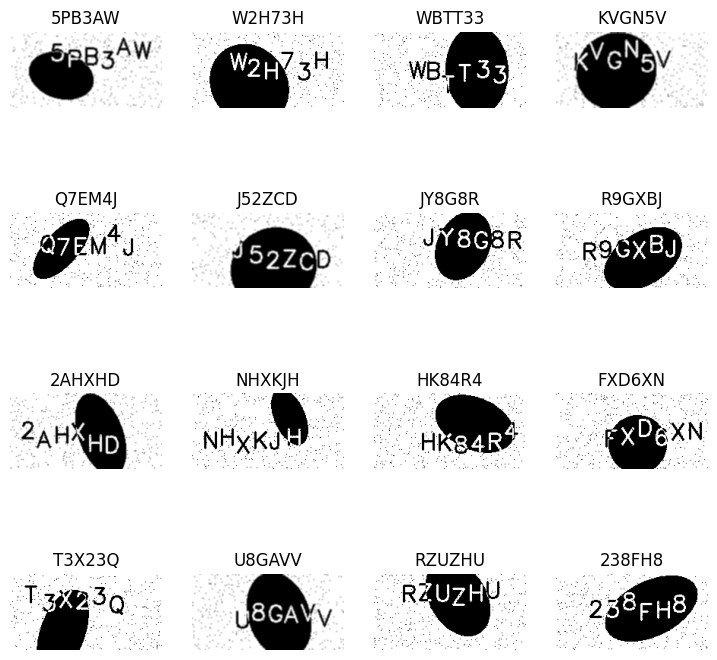

In [10]:
fig = plt.figure(figsize=(9, 9))
rows, cols = 4, 4
for i in range(1, rows * cols + 1):
    random_idx = torch.randint(0, len(train_data), size=[1]).item()
    img, label = train_data[random_idx]
    fig.add_subplot(rows, cols, i)
    if img.ndim == 3 and img.shape[0] == 1:
        plt.imshow(img.squeeze(), cmap="gray")
    else:
        plt.imshow(img.permute(1, 2, 0).cpu())
    plt.title(label)
    plt.axis(False)
plt.show()

All the unique characters in the dataset.All letters and numbers no special characters.

In [11]:
chars = set()

for text in labels_df["text"].astype(str):
    chars.update(text)

print("Unique characters:", sorted(chars))
print("Count:", len(chars))

Unique characters: ['2', '3', '4', '5', '6', '7', '8', '9', 'A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'J', 'K', 'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z']
Count: 31


Image dimension is not too big so no need to resize it .

In [12]:
img,label=train_data[0]
img.shape

torch.Size([1, 100, 200])

Creating a dictionary to map the characters with numbers .

In [13]:
vocab = sorted(chars)
char_to_idx = {c: i + 1 for i, c in enumerate(vocab)}  # 0 reserved for CTC blank
idx_to_char = {i + 1: c for i, c in enumerate(vocab)}
num_classes = len(vocab) + 1
print(char_to_idx)

{'2': 1, '3': 2, '4': 3, '5': 4, '6': 5, '7': 6, '8': 7, '9': 8, 'A': 9, 'B': 10, 'C': 11, 'D': 12, 'E': 13, 'F': 14, 'G': 15, 'H': 16, 'J': 17, 'K': 18, 'M': 19, 'N': 20, 'P': 21, 'Q': 22, 'R': 23, 'S': 24, 'T': 25, 'U': 26, 'V': 27, 'W': 28, 'X': 29, 'Y': 30, 'Z': 31}


a collate function merges a list of individual samples  into a single, unified mini-batch.

In [ ]:
def collate_fn(batch):
    images, labels = zip(*batch)
    images = torch.stack(images, 0)  # (B, 1, H, W)

    # encode labels to indices
    encoded = [torch.tensor([char_to_idx[c] for c in lbl], dtype=torch.long) for lbl in labels]
    label_lengths = torch.tensor([len(e) for e in encoded], dtype=torch.long)
    padded_labels = torch.nn.utils.rnn.pad_sequence(encoded, batch_first=True, padding_value=0)
    #padded sequence is not exactly needed for our data as all of the labels are for length=6 
    #but it is helpful in maintaining reproducibility if data changes

    return images, padded_labels, label_lengths

Dataloader for loading data in batches of 32 to get more updates in weights and efficient use of memory.

In [15]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_data,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_fn
)

val_loader = DataLoader(
    val_data,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_fn
)

For the model we will buld a CRNN with 5 blocks of CNN and a biLSTM .

In [ ]:
class CRNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.cnn = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, kernel_size=3, padding=1),   # (B, 32, 100, 200)
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # (B, 32, 50, 100)

            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),  # (B, 64, 50, 100)
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                            # (B, 64, 25, 50)

            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # (B, 128, 25, 50)
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d((2,1), (2,1)),                    # (B, 128, 12, 50)

            # Block 4
            nn.Conv2d(128, 256, kernel_size=3, padding=1),# (B, 256, 12, 50)
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d((2,1), (2,1)),                    # (B, 256, 6, 50)

            # Block 5
            nn.Conv2d(256, 256, kernel_size=3, padding=1),# (B, 256, 6, 50)
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.MaxPool2d((2,1), (2,1)),                    # (B, 256, 3, 50)
        )

        # After CNN: (B, 256, 3, 50)
        # Collapse height → (B, 50, 256*3) then treat width as time steps
        self.rnn_input_size = 256 * 3
        
        # we are collapsing the height as the the text is written horizontally and the
        #lstm needs the sequential horizontal data to predct not vertical

        # BiLSTM for sequential dependencies
        self.rnn = nn.LSTM(
            input_size=self.rnn_input_size,
            hidden_size=256,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=0.3
        )

        # Final projection to vocab
        self.fc = nn.Linear(256 * 2, num_classes)  # *2 for bidirectional

    def forward(self, x):
        # x: (B, 1, 100, 200)
        x = self.cnn(x)                          # (B, 256, 3, 50)
        B, C, H, W = x.shape
        x = x.permute(0, 3, 1, 2)               # (B, W, C, H) = (B, 50, 256, 3)
        x = x.reshape(B, W, C * H)              # (B, 50, 768)
        x, _ = self.rnn(x)                       # (B, 50, 512)
        x = self.fc(x)                           # (B, 50, num_classes)
        x = x.permute(1, 0, 2)                  # (T, B, num_classes) — CTC expects this
        return x
        

Setup device-agnostic code for selecting gpu if available.

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [18]:
model = CRNN(num_classes=num_classes).to(device)

Initializing loss function ,optimizer and learning rate scheduler . As  preovided i am using CTC (Connectionist Temporal Classification) loss.

In [19]:
from torch.nn import CTCLoss
from torch.optim import Adam
import jiwer 

loss_fn =nn.CTCLoss(blank=0, reduction='mean', zero_infinity=True)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

Helper functions

In [ ]:
#Gives the predicted string from the model logits by choosng the most likely
# one and using the idx_to char map 
def greedy_decode(log_probs, idx_to_char):
    # log_probs: (T, B, num_classes)
    preds = log_probs.argmax(dim=2)   # (T, B)  best class at each timestep
    preds = preds.permute(1, 0)       # (B, T)
    results = []
    for pred in preds:
        chars = []
        prev = None
        for p in pred:
            p = p.item()
            if p != 0 and p != prev:  # skip blank(0) and repeats
                chars.append(idx_to_char[p])
            prev = p
        results.append("".join(chars))
    return results

# CER helper function
def compute_cer(preds, targets):
    # character level matching is required so  treat each  char as a "word" for jiwer
    preds_spaced   = [" ".join(list(p)) for p in preds]
    targets_spaced = [" ".join(list(t)) for t in targets]
    return jiwer.wer(targets_spaced, preds_spaced)  # WER  on chars = CER


Training loop

In [ ]:
import torch.nn.functional as F
from tqdm.auto import tqdm#for progress bar
from timeit import default_timer as timer

best_val_cer = float("inf")
epochs = 30
train_start = timer()

for epoch in tqdm(range(epochs)):
    # ── train ──
    model.train()
    train_loss = 0

    for images, padded_labels, label_lengths in train_loader:
        images        = images.to(device)
        padded_labels = padded_labels.to(device)
        label_lengths = label_lengths.to(device)

        optimizer.zero_grad()

        log_probs = F.log_softmax(model(images), dim=2)  # (T, B, C)
        T, B, _ = log_probs.shape
        input_lengths = torch.full((B,), T, dtype=torch.long).to(device)

        loss = loss_fn(log_probs, padded_labels, input_lengths, label_lengths)
        loss.backward()

        nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)  # stability
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    #validation loop
    model.eval()
    val_loss = 0
    results, all_targets = [], []

    with torch.inference_mode():
        for images, padded_labels, label_lengths in val_loader:
            images        = images.to(device)
            padded_labels = padded_labels.to(device)
            label_lengths = label_lengths.to(device)

            log_probs = F.log_softmax(model(images), dim=2)
            T, B, _ = log_probs.shape
            input_lengths = torch.full((B,), T, dtype=torch.long).to(device)

            loss = loss_fn(log_probs, padded_labels, input_lengths, label_lengths)
            val_loss += loss.item()

            preds = greedy_decode(log_probs.cpu(), idx_to_char)
            # decode targets back to strings
            targets = []
            for i in range(B):
                t = padded_labels[i][:label_lengths[i]].cpu().tolist()
                targets.append("".join([idx_to_char[c] for c in t]))

            results.extend(preds)
            all_targets.extend(targets)

    val_loss /= len(val_loader)
    val_cer = compute_cer(results, all_targets)
    scheduler.step(val_cer)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Val CER: {val_cer:.4f}")

    # save best model
    if val_cer < best_val_cer:
        best_val_cer = val_cer
        torch.save(model.state_dict(), "best_crnn.pth")
        print(f"  ✓ Best model saved (CER: {val_cer:.4f})")

print(f"\nTraining done in {timer() - train_start:.1f}s | Best Val CER: {best_val_cer:.4f}")

c:\Users\Akhil\Desktop\Projects\Distorted Visual Sequence Pattern Recognition\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
  3%|▎         | 1/30 [01:14<35:49, 74.13s/it]

Epoch 1/30 | Train Loss: 4.0447 | Val Loss: 3.5822 | Val CER: 0.9450
  ✓ Best model saved (CER: 0.9450)


  7%|▋         | 2/30 [02:26<34:11, 73.25s/it]

Epoch 2/30 | Train Loss: 3.5735 | Val Loss: 3.5765 | Val CER: 0.9412
  ✓ Best model saved (CER: 0.9412)


 10%|█         | 3/30 [03:40<33:08, 73.63s/it]

...

Epoch 28/30 | Train Loss: 0.0005 | Val Loss: 0.0017 | Val CER: 0.0006


 97%|█████████▋| 29/30 [35:30<01:13, 73.30s/it]

Epoch 29/30 | Train Loss: 0.0004 | Val Loss: 0.0016 | Val CER: 0.0003
  ✓ Best model saved (CER: 0.0003)


100%|██████████| 30/30 [36:43<00:00, 73.44s/it]

Epoch 30/30 | Train Loss: 0.0003 | Val Loss: 0.0013 | Val CER: 0.0003

Training done in 2203.3s | Best Val CER: 0.0003


In [ ]:
for i in range(10):
    print(f"Target: {all_targets[i]} | Pred: {results[i]}")
#testing if the model is predicting useful outputs

Target: 7QKJ6A | Pred: 7QKJ6A
Target: HZF7HS | Pred: HZF7HS
Target: XNWS8B | Pred: XNWS8B
Target: BC5G5A | Pred: BC5G5A
Target: SDQ2S5 | Pred: SDQ2S5
Target: WXF6NV | Pred: WXF6NV
Target: SEW22K | Pred: SEW22K
Target: U7SH7B | Pred: U7SH7B
Target: C7NSAF | Pred: C7NSAF
Target: GB3S3A | Pred: GB3S3A


In [23]:
model.load_state_dict(torch.load("best_crnn.pth",map_location=device))

<All keys matched successfully>

Example prediction and actual labels in the validation dataset.

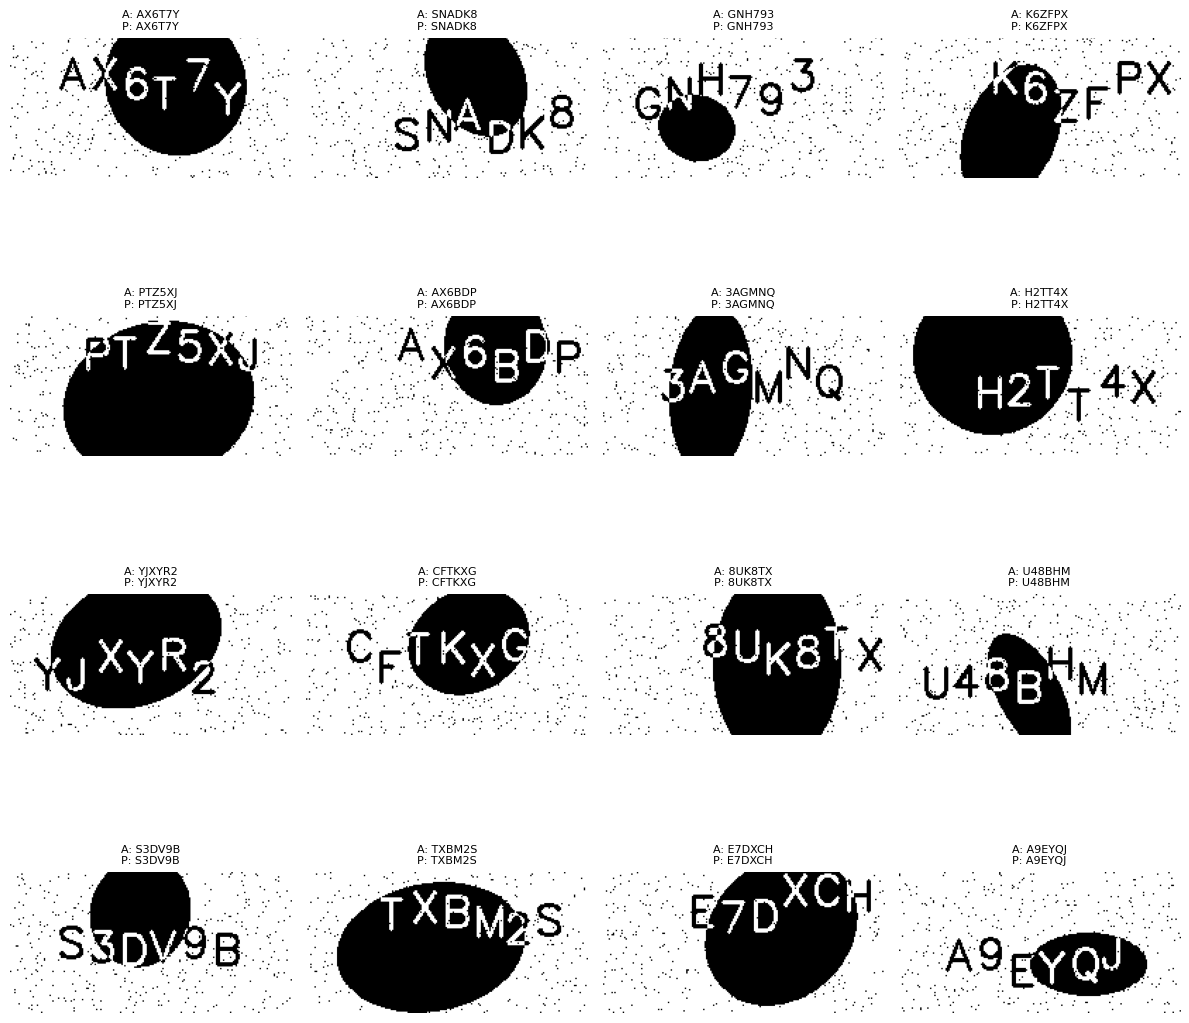

In [24]:
fig = plt.figure(figsize=(12, 12))
rows, cols = 4, 4
model.eval()

with torch.inference_mode():
    for i in range(1, rows * cols + 1):
        random_idx = torch.randint(0, len(val_data), size=[1]).item()
        img, label = val_data[random_idx]

        input_img = img.unsqueeze(0).to(device)
        log_probs = F.log_softmax(model(input_img), dim=2)
        pred = greedy_decode(log_probs.cpu(), idx_to_char)[0]

        fig.add_subplot(rows, cols, i)
        plt.imshow(img.squeeze(), cmap="gray")
        plt.title(f'A: {label}\nP: {pred}', fontsize=8)
        plt.axis(False)

plt.tight_layout()
plt.show()

Creating Test dataset  similar to the train dataset .

In [25]:
class TestImageDataset(Dataset):
    def __init__(self, root, transform=None):
        self.root = root
        self.transform = transform
        self.samples = sorted(
            [f for f in os.listdir(root) if f.lower().endswith(".png")]
        )

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        filename = self.samples[idx]
        path = os.path.join(self.root, filename)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(4,4))
        img = clahe.apply(img)
        image = Image.fromarray(img)
        if self.transform is not None:
            image = self.transform(image)
        return image ,filename

In [26]:
test_dir = "data/cig_ps/test_images"
test_dataset = TestImageDataset(test_dir, transform=val_transform)

In [27]:
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
)

Predicting on the given test dataset.

In [ ]:
model.eval()
results = []
filenames = []

with torch.inference_mode():
    for images, filenames in test_loader:  # test loader returns (image, filename)
        images = images.to(device)

        log_probs = F.log_softmax(model(images), dim=2)
        preds = greedy_decode(log_probs.cpu(), idx_to_char)

        results.extend(preds)
        filenames.extend(filenames)

Final submisiion file according to the given format.

In [ ]:
submission = pd.DataFrame({
    "image": filenames,
    "prediction": results
})
submission.to_csv("submission_Akhil_Kumar_24117009.csv", index=False)
print(submission.head())

           image prediction
0     test-0.png     QVTQ8A
1     test-1.png     7PSW9D
2    test-10.png     7DUP98
3   test-100.png     75Z4WT
4  test-1000.png     QAKZ7V


Resaved the submission file as the predictions were not in order by filename

In [ ]:
import pandas as pd
submission = pd.read_csv("submission_Akhil_Kumar_24117009.csv")
submission["num"] = submission["image"].apply(
    lambda x: int(x.split("-")[1].split(".")[0])
)
submission = submission.sort_values("num").drop(columns=["num"]).reset_index(drop=True)
submission.to_csv("submission_Akhil_Kumar_24117009.csv", index=False)
print(submission.head(10))

        image prediction
0  test-0.png     QVTQ8A
1  test-1.png     7PSW9D
2  test-2.png     WJ2WNY
3  test-3.png     RFHJD4
4  test-4.png     K7ZUF2
5  test-5.png     CPMUBK
6  test-6.png     UZDRAW
7  test-7.png     2YDPJR
8  test-8.png     H5SG63
9  test-9.png     B2Z823
